Installing packages

In [1]:
!pip install rdkit pandas numpy matplotlib seaborn scikit-learn

Cloning repo

In [2]:
import os

REPO_ROOT = "/content/REINVENT_Boltz_Pipeline"

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/ibrahimwichka/REINVENT_Boltz_Pipeline.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull origin main

print(os.path.exists(REPO_ROOT))

From https://github.com/ibrahimwichka/REINVENT_Boltz_Pipeline
 * branch            main       -> FETCH_HEAD
Already up to date.
True


Setting target, iteration, and data paths

In [3]:
from pathlib import Path

# --- The only lines that change between targets/iterations ---
TARGET_NAME = "CDK2" # or "P38_MAPK14"
ITERATION = 1
ACTIVES_BASELINE = "CDK2_actives_baseline_profile.csv" # or "P38_MAPK14_..."
ANALYSIS_SUBFOLDER = "CDK2_analysis" #or "P38_MAPK14_analysis"
# ---------------------------------------------------------------

REPO_ROOT_PATH = Path(REPO_ROOT)
GENERATED_PATH = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "generation" / "generated_molecules.csv")
BASELINE_PATH = (REPO_ROOT_PATH / "target_mols" / TARGET_NAME / "analysis"
/ ANALYSIS_SUBFOLDER / ACTIVES_BASELINE)
ANALYSIS_DIR = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(GENERATED_PATH.exists())
print(BASELINE_PATH.exists())
print(ANALYSIS_DIR)

True
True
/content/REINVENT_Boltz_Pipeline/iterations/CDK2/1/analysis


Imports

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem import FilterCatalog
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from rdkit.Chem import AllChem, MACCSkeys, Fragments 
from rdkit.Avalon import pyAvalonTools
from rdkit.ML.Cluster import Butina

sns.set_theme(style="whitegrid")


In [5]:
!mkdir -p /content/sa_score
!curl -L -o /content/sa_score/sascorer.py \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!curl -L -o /content/sa_score/fpscores.pkl.gz \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5913  100  5913    0     0  24845      0 --:--:-- --:--:-- --:--:-- 24949
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3758k  100 3758k    0     0  3722k      0  0:00:01  0:00:01 --:--:-- 3724k


Loading generated molecules and actives baseline

In [6]:
generated_raw = pd.read_csv(GENERATED_PATH)
print(TARGET_NAME, "Iteration", ITERATION, "generated:", generated_raw.shape)
generated_raw.head()

baseline = pd.read_csv(BASELINE_PATH)
print(TARGET_NAME, "actives baseline:", baseline.shape)
baseline.head()

CDK2 Iteration 1 generated: (4877, 3)
CDK2 actives baseline: (1402, 20)


,canonical_smiles,MW,cLogP,HBD,HBA,TPSA,QED,SA_score,scaffold,has_hydroxyl,has_amine,has_carbonyl,has_amide,has_halogen_F,has_halogen_Cl,has_halogen_Br,has_aromatic_ring,has_piperidine,has_piperazine,has_morpholine
0,O=[N+]([O-])c1cccc(Nc2nccc(-c3cnn4ncccc34)n2)c1,333.311,2.83810,1,7,111.14,0.451249,2.562189,c1ccc(Nc2nccc(-c3cnn4ncccc34)n2)cc1,False,True,False,False,False,False,False,True,False,False,False
1,NS(=O)(=O)c1ccc(Nc2cc(-c3ccc([N+](=O)[O-])cc3)...,359.367,2.37590,3,6,144.01,0.471015,2.220594,c1ccc(Nc2cc(-c3ccccc3)[nH]n2)cc1,False,True,False,False,False,False,False,True,False,False,False
2,Nc1ccc(-c2cc(Nc3ccc(S(N)(=O)=O)cc3)[nH]n2)cc1,329.385,2.04990,4,5,126.89,0.544792,2.326835,c1ccc(Nc2cc(-c3ccccc3)n[nH]2)cc1,False,True,False,False,False,False,False,True,False,False,False
3,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,466.541,4.35400,2,4,69.45,0.405842,4.953656,O=C1NCc2c1c1c3ccccc3n3c1c1c2c2ccccc2n1C1CCC[C@...,False,True,True,True,False,False,False,True,False,False,False
4,CC(=O)NC1CN(c2ccc(Nc3ncc(F)c(-c4cnc(C)n4C(C)C)...,423.496,3.43682,2,6,87.97,0.631580,2.756320,c1cc(-c2cnc[nH]2)nc(Nc2ccc(N3CCC3)cc2)n1,False,True,True,True,True,False,False,True,False,False,False


Cleaning and canonicalizing generated molecules

In [7]:
def canonicalize(smiles):
# Return a canonical SMILES string, or None if RDKit can’t parse it
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

def clean_generated(df_raw, smiles_col):
    df = df_raw.copy()
    df["canonical_smiles"] = df[smiles_col].apply(canonicalize)
    n_before = len(df)
    df = df.dropna(subset=["canonical_smiles"])
    df = df.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
    print(f"kept {len(df)} of {n_before} rows after canonicalization + dedup")
    return df

gen_df = clean_generated(generated_raw, smiles_col="SMILES")

kept 4877 of 4877 rows after canonicalization + dedup


Recomputing descriptors, QED, SA score, scaffold, and functional
groups

In [8]:
def add_descriptors(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["MW"] = [Descriptors.MolWt(m) for m in mols]
    df["cLogP"] = [Crippen.MolLogP(m) for m in mols]
    df["HBD"] = [Lipinski.NumHDonors(m) for m in mols]
    df["HBA"] = [Lipinski.NumHAcceptors(m) for m in mols]
    df["TPSA"] = [rdMolDescriptors.CalcTPSA(m) for m in mols]
    return df

def add_qed(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["QED"] = [QED.qed(m) for m in mols]
    return df


import sys
sys.path.append("/content/sa_score")
import sascorer

def add_sa_score(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["SA_score"] = [sascorer.calculateScore(m) for m in mols]
    return df

def add_scaffold(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["scaffold"] = [
        Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)) for m in mols
        ]
    return df

FUNCTIONAL_GROUP_SMARTS = {
    "hydroxyl": "[OX2H]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carbonyl": "[CX3]=[OX1]",
    "amide": "C(=O)N",
    "halogen_F": "[#9]",
    "halogen_Cl": "[#17]",
    "halogen_Br": "[#35]",
    "aromatic_ring": "a1aaaaa1",
    "piperidine": "C1CCNCC1",
    "piperazine": "C1CNCCN1",
    "morpholine": "C1COCCN1",
    }
FUNCTIONAL_GROUP_PATTERNS = {
name: Chem.MolFromSmarts(smarts) for name, smarts in FUNCTIONAL_GROUP_SMARTS.items()
}

def add_functional_group_flags(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    for name, patt in FUNCTIONAL_GROUP_PATTERNS.items():
        df[f"has_{name}"] = [m.HasSubstructMatch(patt) for m in mols]
    return df

gen_df = add_descriptors(gen_df)
gen_df = add_qed(gen_df)
gen_df = add_sa_score(gen_df)
gen_df = add_scaffold(gen_df)
gen_df = add_functional_group_flags(gen_df)

gen_df[["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]].describe()

,MW,cLogP,HBD,HBA,TPSA,QED,SA_score
count,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000
mean,356.315799,3.311998,1.285216,4.177363,68.034084,0.608739,2.996304
std,128.891722,2.308438,1.167676,2.073979,36.810557,0.221624,0.791418
min,87.078000,-9.110400,0.000000,0.000000,0.000000,0.011203,1.430026
25%,266.772000,1.949200,1.000000,3.000000,43.370000,0.459394,2.436342
50%,336.355000,3.056300,1.000000,4.000000,64.150000,0.655792,2.840714
75%,423.192000,4.301000,2.000000,5.000000,86.630000,0.788981,3.395005
max,1311.789000,26.279400,17.000000,24.000000,468.230000,0.947447,7.755449


Overlaid distribution comparisons

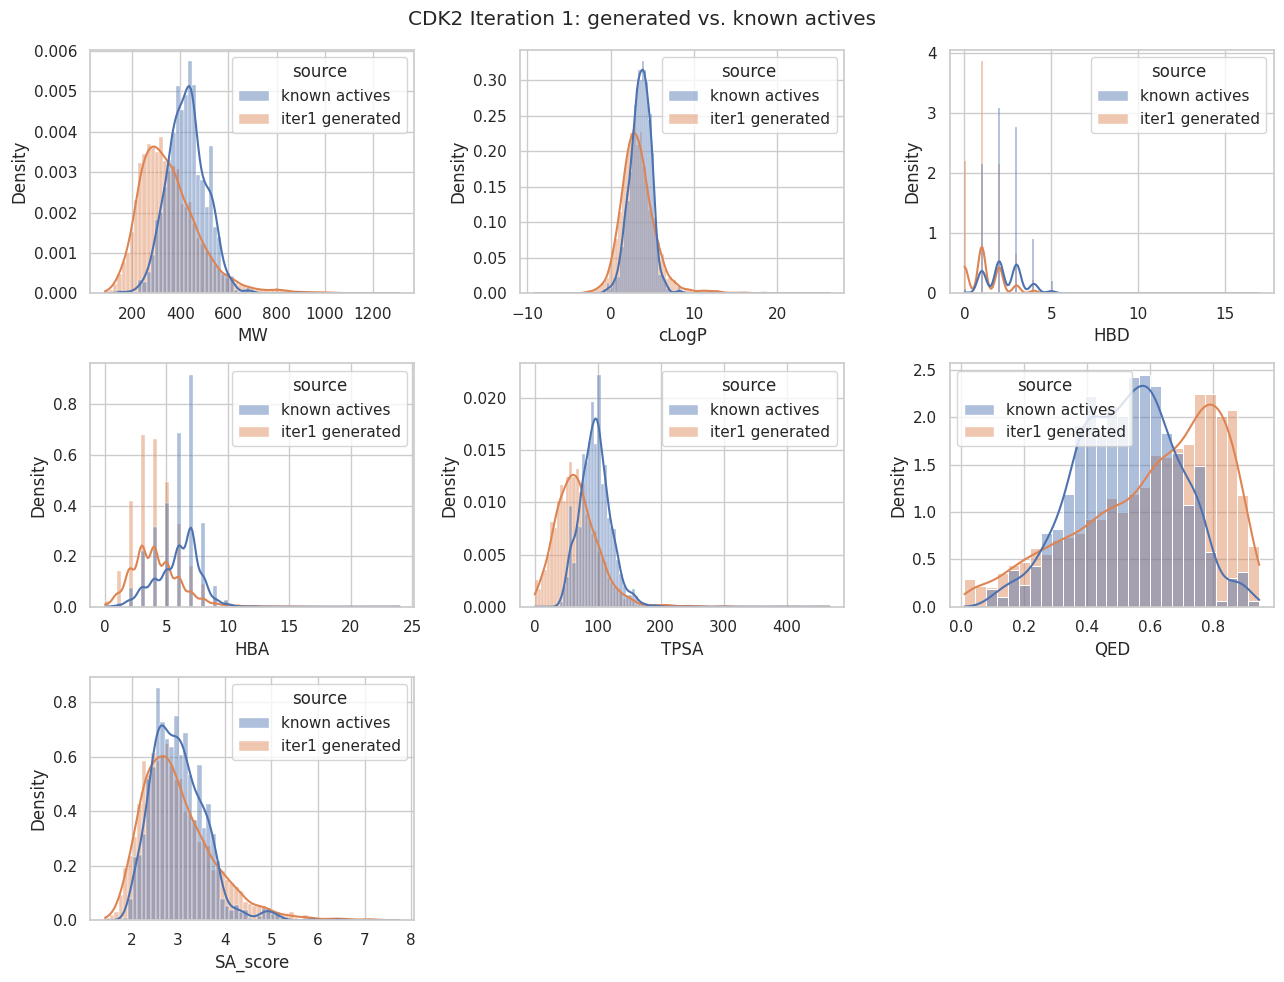

In [9]:
DESCRIPTOR_COLS = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]

compare_long = pd.concat([
    baseline[DESCRIPTOR_COLS].assign(source="known actives"),
    gen_df[DESCRIPTOR_COLS].assign(source=f"iter{ITERATION} generated"),
    ], ignore_index=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, DESCRIPTOR_COLS):
    sns.histplot(data=compare_long, x=col, hue="source", stat="density", 
                 common_norm=False, kde=True, alpha=0.45, ax=ax)
for ax in axes.flat[len(DESCRIPTOR_COLS):]:
    ax.set_visible(False)
fig.suptitle(f"{TARGET_NAME} Iteration {ITERATION}: generated vs. known actives")
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_descriptor_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Scaffold diversity and overlap

CDK2 iter1: 3726 unique scaffolds across 4877 generated molecules
CDK2 actives: 603 unique scaffolds across 1402 molecules
Scaffolds appearing in BOTH sets: 8


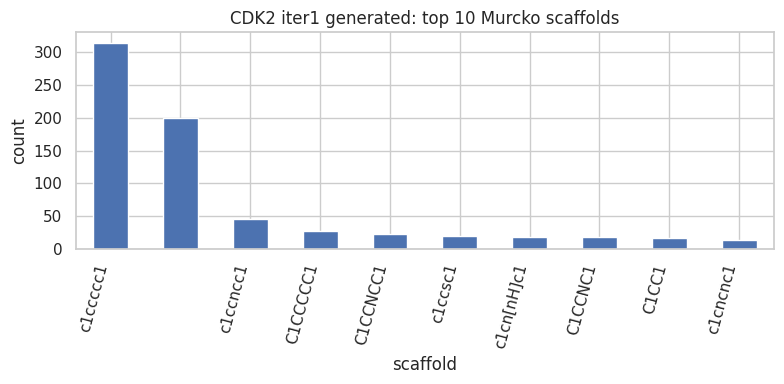

In [10]:
n_gen_scaffolds = gen_df["scaffold"].nunique()
n_act_scaffolds = baseline["scaffold"].nunique()
shared_scaffolds = set(gen_df["scaffold"]) & set(baseline["scaffold"])

print(f"{TARGET_NAME} iter{ITERATION}: {n_gen_scaffolds} unique scaffolds "
    f"across {len(gen_df)} generated molecules")
print(f"{TARGET_NAME} actives: {n_act_scaffolds} unique scaffolds "
    f"across {len(baseline)} molecules")
print(f"Scaffolds appearing in BOTH sets: {len(shared_scaffolds)}")

top_gen_scaffolds = gen_df["scaffold"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_gen_scaffolds.plot(kind="bar", ax=ax)
ax.set_ylabel("count")
ax.set_title(f"{TARGET_NAME} iter{ITERATION} generated: top 10 Murcko scaffolds")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_top_scaffolds.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Functional group frequency comparison

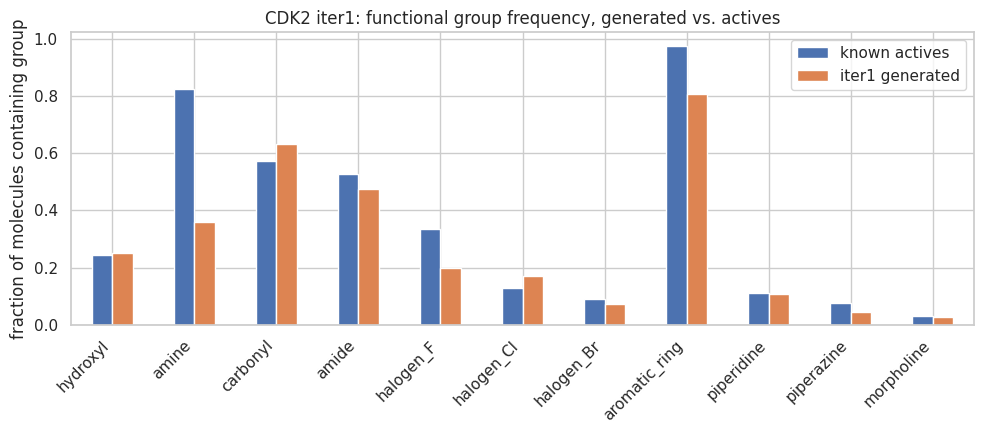

In [11]:
flag_cols = [f"has_{name}" for name in FUNCTIONAL_GROUP_SMARTS]

freq_compare = pd.DataFrame({
    "known actives": baseline[flag_cols].mean(),
    f"iter{ITERATION} generated": gen_df[flag_cols].mean(),
    })
freq_compare.index = [c.replace("has_", "") for c in freq_compare.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
freq_compare.plot(kind="bar", ax=ax)
ax.set_ylabel("fraction of molecules containing group")
ax.set_title(f"{TARGET_NAME} iter{ITERATION}: functional group frequency, " 
             "generated vs. actives")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_functional_group_frequency.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Cross-set Tanimoto similarity to known actives

In [12]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def add_fingerprints(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["fingerprint"] = [morgan_gen.GetFingerprint(m) for m in mols]
    return df

gen_df = add_fingerprints(gen_df)
baseline_fps_df = add_fingerprints(baseline.rename(columns={"canonical_smiles": 
        "canonical_smiles"}))
active_fps = list(baseline_fps_df["fingerprint"])

def nearest_active(fp):
    #Return (max Tanimoto similarity, index into baseline of the nearest active).
    sims = DataStructs.BulkTanimotoSimilarity(fp, active_fps)
    best_idx = int(np.argmax(sims))
    return sims[best_idx], best_idx

results = [nearest_active(fp) for fp in gen_df["fingerprint"]]
gen_df["nearest_active_sim"] = [r[0] for r in results]
gen_df["nearest_active_idx"] = [r[1] for r in results]

print(f"{TARGET_NAME} iter{ITERATION}: mean nearest-active Tanimoto = "
      f"{gen_df['nearest_active_sim'].mean():.3f}, "
      f"max = {gen_df['nearest_active_sim'].max():.3f}")

CDK2 iter1: mean nearest-active Tanimoto = 0.232, max = 0.548


Rediscovery hit detection

In [13]:
THETA_HIT = 0.85 # research plan Section 1.5: near-identical scaffold
THETA_EXACT = 1.0 # exact canonical SMILES match

hits = gen_df[gen_df["nearest_active_sim"] >= THETA_HIT].copy()
exact_hits = gen_df[gen_df["nearest_active_sim"] >= THETA_EXACT].copy()

print(f"{TARGET_NAME} iter{ITERATION}: {len(hits)} rediscovery hit(s) "
    f"(sim >= {THETA_HIT}) out of {len(gen_df)} generated molecules")
print(f" of which {len(exact_hits)} are exact matches (sim = 1.0)")

if len(hits) == 0:
    print("\nNo hits yet -- expected for Iteration 1. See the closest pairs below "
    "instead; re-run this exact cell on later iterations to watch this "
    "number move.")


CDK2 iter1: 0 rediscovery hit(s) (sim >= 0.85) out of 4877 generated molecules
 of which 0 are exact matches (sim = 1.0)

No hits yet -- expected for Iteration 1. See the closest pairs below instead; re-run this exact cell on later iterations to watch this number move.


Visualizing the closest pairs

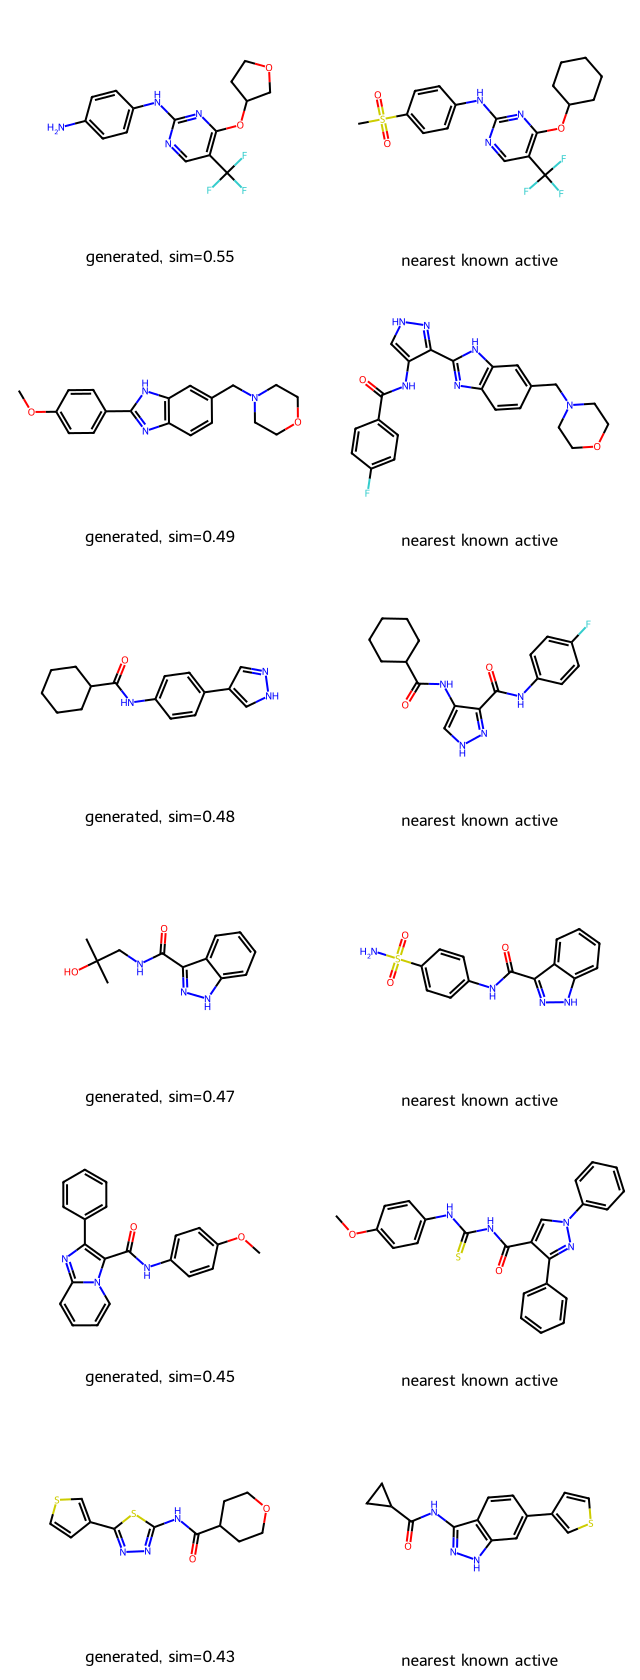

In [14]:
N_SHOW = 6
top_pairs = gen_df.sort_values("nearest_active_sim", ascending=False).head(N_SHOW)

mols_to_draw = []
legends = []
for _, row in top_pairs.iterrows():
    gen_mol = Chem.MolFromSmiles(row["canonical_smiles"])
    act_row = baseline.iloc[row["nearest_active_idx"]]
    act_mol = Chem.MolFromSmiles(act_row["canonical_smiles"])
    
    mols_to_draw += [gen_mol, act_mol]
    legends += [
        f"generated, sim={row['nearest_active_sim']:.2f}",
        "nearest known active",
    ]

img = Draw.MolsToGridImage(
    mols_to_draw, molsPerRow=2, subImgSize=(320, 280), legends=legends, 
    returnPNG=False 
    )
img.save(str(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_closest_pairs.png"))
img

PCA - Projecting generated molecules into actives' descriptor space

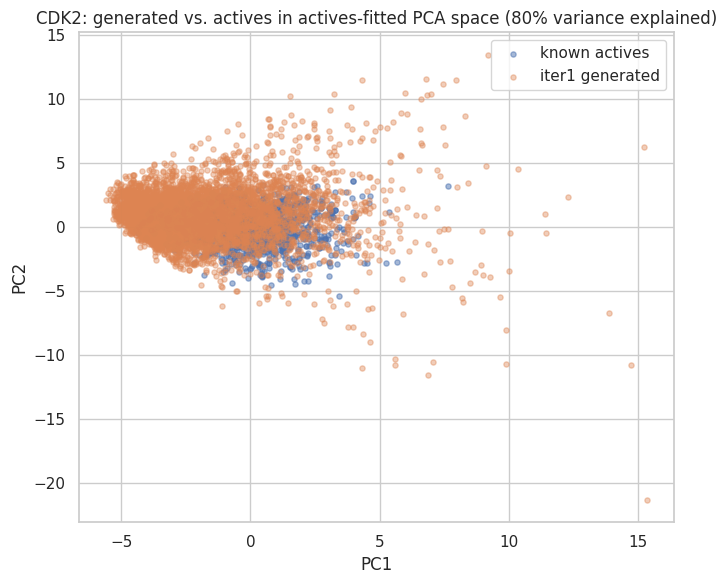

In [15]:
feature_cols = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED"]

scaler = StandardScaler().fit(baseline[feature_cols])
pca = PCA(n_components=2).fit(scaler.transform(baseline[feature_cols]))

act_pca = pca.transform(scaler.transform(baseline[feature_cols]))
gen_pca = pca.transform(scaler.transform(gen_df[feature_cols]))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(act_pca[:, 0], act_pca[:, 1], alpha=0.5, s=14, label="known actives")
ax.scatter(gen_pca[:, 0], gen_pca[:, 1], alpha=0.4, s=14,
           label=f"iter{ITERATION} generated")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"{TARGET_NAME}: generated vs. actives in actives-fitted PCA space "
             f"({pca.explained_variance_ratio_.sum():.0%} variance explained)")
ax.legend()
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_pca_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

PAINS screening on closest candidates

In [16]:
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog.FilterCatalog(params)

def pains_flags(smiles_list):
    flagged = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        match = pains_catalog.GetFirstMatch(mol)
        flagged.append(match.GetDescription() if match else None)
    return flagged

top_pairs = top_pairs.copy()
top_pairs["pains_flag"] = pains_flags(top_pairs["canonical_smiles"])
top_pairs[["canonical_smiles", "nearest_active_sim", "pains_flag"]]

,canonical_smiles,nearest_active_sim,pains_flag
750,Nc1ccc(Nc2ncc(C(F)(F)F)c(OC3CCOC3)n2)cc1,0.548387,anil_no_alk(40)
4724,COc1ccc(-c2nc3ccc(CN4CCOCC4)cc3[nH]2)cc1,0.486111,None
4419,O=C(Nc1ccc(-c2cn[nH]c2)cc1)C1CCCCC1,0.481481,None
3757,CC(C)(O)CNC(=O)c1n[nH]c2ccccc12,0.470588,None
372,COc1ccc(NC(=O)c2c(-c3ccccc3)nc3ccccn23)cc1,0.453125,None
1551,O=C(Nc1nnc(-c2ccsc2)s1)C1CCOCC1,0.431034,None


More properties (clustering based on molecular fingerprints and functional groups)


[morgan] 4494 clusters found (4263 single-molecule clusters, largest = 28 molecules)


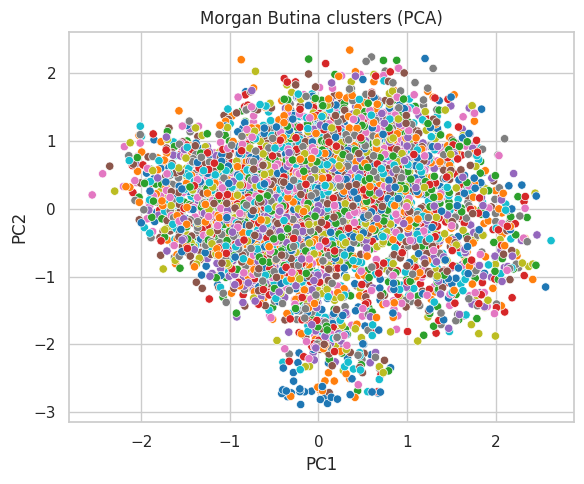

Top functional groups per cluster (morgan)

Cluster 0 (n=28):
fr_unbrch_alkane    20.000000
fr_allylic_oxid      6.607143
fr_ether             2.464286
fr_C_O               2.107143
fr_C_O_noCOO         2.071429

Cluster 1 (n=11):
fr_unbrch_alkane    28.000000
fr_allylic_oxid      2.363636
fr_Al_OH_noTert      2.090909
fr_Al_OH             2.090909
fr_C_O               1.000000

Cluster 2 (n=9):
fr_NH1          2.777778
fr_C_O          2.444444
fr_C_O_noCOO    1.777778
fr_amide        1.555556
fr_benzene      1.444444

Cluster 3 (n=9):
fr_benzene      1.777778
fr_C_O_noCOO    1.555556
fr_C_O          1.555556
fr_amide        1.555556
fr_NH1          1.444444

Cluster 4 (n=8):
fr_C_O          5.500
fr_C_O_noCOO    3.875
fr_amide        3.625
fr_NH1          3.250
fr_NH2          2.500

Cluster 5 (n=7):
fr_benzene      2.714286
fr_C_O_noCOO    2.142857
fr_C_O          2.142857
fr_amide        2.142857
fr_NH0          1.714286

Cluster 6 (n=6):
fr_benzene      3.000000
fr_ether        2.6

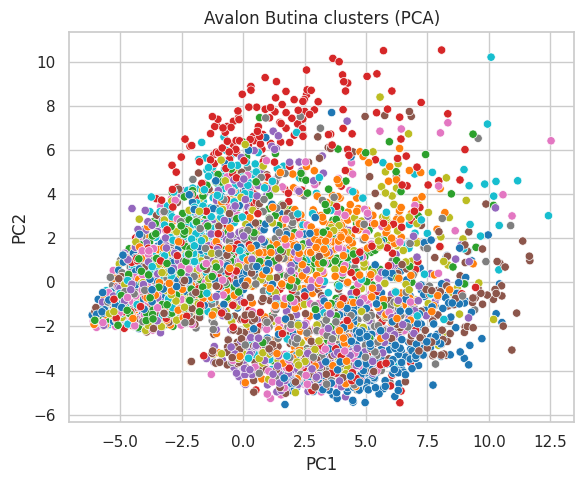

Top functional groups per cluster (avalon)

Cluster 0 (n=246):
fr_NH0            3.304878
fr_Ar_N           2.711382
fr_C_O            1.154472
fr_aryl_methyl    1.097561
fr_C_O_noCOO      1.085366

Cluster 1 (n=167):
fr_NH0         1.862275
fr_benzene     1.724551
fr_Ar_N        1.670659
fr_bicyclic    1.431138
fr_NH1         0.946108

Cluster 2 (n=131):
fr_benzene      1.732824
fr_NH0          1.175573
fr_sulfonamd    0.977099
fr_NH1          0.961832
fr_C_O          0.893130

Cluster 3 (n=107):
fr_bicyclic     2.803738
fr_C_O          2.037383
fr_C_O_noCOO    1.869159
fr_ether        1.532710
fr_NH0          1.514019

Cluster 4 (n=93):
fr_NH0          1.268817
fr_NH1          1.043011
fr_Ar_N         1.021505
fr_C_O          0.752688
fr_C_O_noCOO    0.655914

Cluster 5 (n=92):
fr_NH0         4.380435
fr_Ar_N        4.173913
fr_bicyclic    1.391304
fr_benzene     1.228261
fr_NH1         1.184783

Cluster 6 (n=83):
fr_benzene      1.987952
fr_C_O          1.746988
fr_C_O_noCOO    1.71

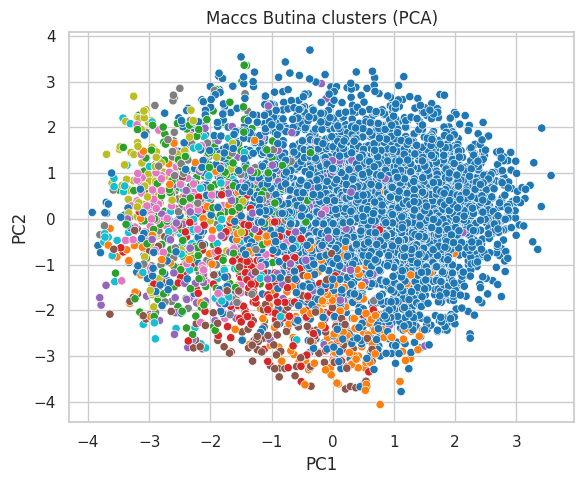

Top functional groups per cluster (maccs)

Cluster 0 (n=3296):
fr_NH0          2.060073
fr_Ar_N         1.234223
fr_benzene      1.209951
fr_C_O          1.174454
fr_C_O_noCOO    1.083738

Cluster 1 (n=192):
fr_NH0            2.296875
fr_Ar_N           1.869792
fr_benzene        1.343750
fr_bicyclic       0.843750
fr_aryl_methyl    0.713542

Cluster 2 (n=171):
fr_unbrch_alkane    1.888889
fr_C_O              0.707602
fr_NH0              0.666667
fr_C_O_noCOO        0.643275
fr_NH1              0.514620

Cluster 3 (n=144):
fr_benzene      1.500000
fr_NH0          1.083333
fr_C_O          0.881944
fr_NH1          0.777778
fr_C_O_noCOO    0.743056

Cluster 4 (n=137):
fr_benzene      1.153285
fr_halogen      0.773723
fr_NH1          0.759124
fr_NH0          0.700730
fr_sulfonamd    0.605839

Cluster 5 (n=97):
fr_NH0         2.041237
fr_Ar_N        1.979381
fr_benzene     1.577320
fr_bicyclic    1.123711
fr_halogen     0.865979

Cluster 6 (n=77):
fr_benzene         1.467532
fr_ether        

In [17]:
gen_df["mol"] = gen_df["canonical_smiles"].apply(Chem.MolFromSmiles)
mols = gen_df["mol"].tolist()

# Computing fingerprints (Morgan, Avalon, MACCS)
def get_fingerprints(mols, fp_type="morgan", n_bits=2048, radius=2):
    # Returns a list of RDKit fingerprint vectors 
    if fp_type == "morgan":
        if "fingerprint" in gen_df.columns:
            return list(gen_df["fingerprint"])
        generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        return [generator.GetFingerprint(mol) for mol in mols]
    elif fp_type == "avalon":
        return [pyAvalonTools.GetAvalonFP(mol, nBits=n_bits) for mol in mols]
    elif fp_type == "maccs":
        return [MACCSkeys.GenMACCSKeys(mol) for mol in mols] 
    else:
        raise ValueError(f"Unknown fp_type: {fp_type}")


# Butina clustering on Tanimoto distance
def butina_cluster(fps, cutoff=0.6):
    # cutoff = Tanimoto distance threshold (1 - similarity) 
    n = len(fps)
    dists = []
    for i in range(1, n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - s for s in sims])

    clusters = Butina.ClusterData(dists, n, cutoff, isDistData=True)
    clusters_by_size = sorted(clusters, key=len, reverse=True)

    labels = np.empty(n, dtype=int)
    for cluster_id, member_indices in enumerate(clusters_by_size):
        for idx in member_indices:
            labels[idx] = cluster_id
    return labels, clusters_by_size

# Functional group counting 
FRAGMENT_FUNCS = {
    name: func for name, func in Fragments.__dict__.items() if name.startswith("fr_")
}


def compute_functional_groups(mols):
    rows = [{name: func(mol) for name, func in FRAGMENT_FUNCS.items()} for mol in mols]
    return pd.DataFrame(rows)


def top_functional_groups_per_cluster(fg_df, labels, top_n=5):
    fg_df = fg_df.copy()
    fg_df["cluster"] = labels
    results = {}
    for cluster_id, group in fg_df.groupby("cluster"):
        mean_counts = group.drop(columns="cluster").mean().sort_values(ascending=False)
        results[cluster_id] = mean_counts[mean_counts > 0].head(top_n)
    return results


# Clustering visualization
def fps_to_numpy(fps):
    arrs = []
    for fp in fps:
        arr = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        arrs.append(arr)
    return np.array(arrs)


def plot_clusters_pca(fps, labels, title, save_path=None): 
    coords = PCA(n_components=2, random_state=42).fit_transform(fps_to_numpy(fps))
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, palette="tab10", legend=False)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    if save_path: 
        plt.savefig(save_path, dpi=150) 
    plt.show()

# Summary of most common functional groups for the clusters within the different fingerprint types
def summarize_clustering(clusters, fg_df, labels, fp_type):
    n_clusters = len(clusters)
    n_single = sum(1 for c in clusters if len(c) == 1)
    biggest_id = 0  # sorted by size
    biggest_size = len(clusters[0])

    top_groups_biggest = top_functional_groups_per_cluster(fg_df, labels, top_n=3)[biggest_id]
    dominant_group = top_groups_biggest.index[0] if len(top_groups_biggest) else "none"

    return {
        "fingerprint": fp_type,
        "n_molecules": len(labels),
        "n_clusters": n_clusters,
        "n_single_molecule_clusters": n_single,
        "pct_single_molecule": round(100 * n_single / len(labels), 1),
        "biggest_cluster_size": biggest_size,
        "biggest_cluster_dominant_group": dominant_group,
    }


# Generating graph and summary data for each fingerprint type 
FP_TYPES = ["morgan", "avalon", "maccs"]
CUTOFF = 0.6  # Tanimoto distance threshold; can change  

fg_df = compute_functional_groups(mols)
all_labels = {}
summary_rows = []

for fp_type in FP_TYPES:
    fps = get_fingerprints(mols, fp_type=fp_type)
    labels, clusters = butina_cluster(fps, cutoff=CUTOFF)

    gen_df[f"cluster_{fp_type}"] = labels
    all_labels[fp_type] = labels
    summary_rows.append(summarize_clustering(clusters, fg_df, labels, fp_type))

    n_single = sum(1 for c in clusters if len(c) == 1)
    print(f"\n[{fp_type}] {len(clusters)} clusters found "
          f"({n_single} single-molecule clusters, largest = {len(clusters[0])} molecules)")

    plot_clusters_pca(
        fps, labels, title=f"{fp_type.capitalize()} Butina clusters (PCA)",
        save_path=f"{ANALYSIS_DIR}/{fp_type}_clusters_pca.png", 
    )

    print(f"Top functional groups per cluster ({fp_type})")
    top_groups = top_functional_groups_per_cluster(fg_df, labels)
    lines = []
    for cluster_id in sorted(set(labels)):
        n_in_cluster = int((labels == cluster_id).sum())
        block = f"\nCluster {cluster_id} (n={n_in_cluster}):\n{top_groups[cluster_id].to_string()}"
        print(block)
        lines.append(block)

    with open(f"{ANALYSIS_DIR}/{fp_type}_functional_groups.txt", "w") as f:
        f.write("\n".join(lines))



In [18]:
# General summary table
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{ANALYSIS_DIR}/clustering_summary.csv", index=False)
print("\nClustering summary")
summary_df


Clustering summary


,fingerprint,n_molecules,n_clusters,n_single_molecule_clusters,pct_single_molecule,biggest_cluster_size,biggest_cluster_dominant_group
0,morgan,4877,4494,4263,87.4,28,fr_unbrch_alkane
1,avalon,4877,1405,927,19.0,246,fr_NH0
2,maccs,4877,98,35,0.7,3296,fr_NH0


In [19]:
# Most common functional group in the top 20 hits (based on Tanimoto similarity) 
TOP_N_HITS = 20
 
top_hits = gen_df.sort_values("nearest_active_sim", ascending=False).head(TOP_N_HITS).reset_index(drop=True)
top_hits_fg = compute_functional_groups(top_hits["mol"].tolist())
 
# For each hit, find its own single most common functional group (by count)
def top_group_for_row(row):
    if row.max() == 0:
        return "none"
    return row.idxmax().replace("fr_", "")
 
top_hits["top_functional_group"] = top_hits_fg.apply(top_group_for_row, axis=1)
top_hits.drop(columns="mol").to_csv(f"{ANALYSIS_DIR}/top_{TOP_N_HITS}_hits.csv", index=False)
 
print(f"Top {TOP_N_HITS} hits by nearest_active_sim")
top_hits[["canonical_smiles", "nearest_active_sim", "top_functional_group"]]

Top 20 hits by nearest_active_sim


,canonical_smiles,nearest_active_sim,top_functional_group
0,Nc1ccc(Nc2ncc(C(F)(F)F)c(OC3CCOC3)n2)cc1,0.548387,aniline
1,COc1ccc(-c2nc3ccc(CN4CCOCC4)cc3[nH]2)cc1,0.486111,ether
2,O=C(Nc1ccc(-c2cn[nH]c2)cc1)C1CCCCC1,0.481481,NH1
3,CC(C)(O)CNC(=O)c1n[nH]c2ccccc12,0.470588,NH1
4,COc1ccc(NC(=O)c2c(-c3ccccc3)nc3ccccn23)cc1,0.453125,NH0
5,O=C(Nc1nnc(-c2ccsc2)s1)C1CCOCC1,0.431034,NH0
6,CCCC(NS(=O)(=O)c1ccc(Nc2nccc(-c3cccnc3)n2)cc1)...,0.426667,NH0
7,C=CCNC(=O)C(=Cc1cn(-c2ccc(OC)cc2)nc1-c1ccccc1)...,0.425000,C_O
8,COc1ccc(C(=O)N2CCN(S(=O)(=O)NCc3ccncc3)CC2)cc1,0.424242,NH0
9,COc1cccc(C(=O)Nc2ccc(Nc3cc(Cl)ccc3C)cn2)c1,0.424242,aniline


Assembling and saving comparison profile

In [20]:
comparison_cols = [
    "canonical_smiles", "MW", "cLogP", "HBD", "HBA", "TPSA",
    "QED", "SA_score", "scaffold", "nearest_active_sim",
    ] + flag_cols

comparison = gen_df[comparison_cols]
comparison_out = ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_comparison_profile.csv"
comparison.to_csv(comparison_out, index=False)

print("saved:", comparison_out)
print(f"rediscovery hits (sim >= {THETA_HIT}):", len(hits))

saved: /content/REINVENT_Boltz_Pipeline/iterations/CDK2/1/analysis/CDK2_iter1_comparison_profile.csv
rediscovery hits (sim >= 0.85): 0


Bringing everything to laptop (figures, csv)

In [21]:
import shutil
from google.colab import files

zip_base = f"/content/{TARGET_NAME}_iter{ITERATION}_analysis"
shutil.make_archive(zip_base, "zip", ANALYSIS_DIR)
files.download(f"{zip_base}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>